# Item-Item Collaborative Filtering

In [2]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

In [75]:
users_movies = pd.read_csv("users_movies.csv")

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## Create the user-item matrix

In [6]:
def sparse_matrix(df):
    movies = df['movie_id'].nunique()
    users = df['user_id'].nunique()

    x = list(range(movies))
    y = list(range(users))
    a = df["movie_id"]
    b = df["user_id"]
    
    m = dict(zip(np.unique(a), x))
    u = dict(zip(np.unique(b), y))
    m_inv = dict(zip(x, np.unique(a)))
    u_inv = dict(zip(y, np.unique(b)))

    m_idx = [m[i] for i in a]
    u_idx = [u[i] for i in b]
    matrix = csr_matrix((df["rating"], (u_idx,m_idx)), shape=(users,movies))
    return matrix, u, m, u_inv, m_inv

matrix, u, m, u_inv, m_inv = sparse_matrix(train)


In [8]:
matrix.shape

(6040, 3679)

In [10]:
total = matrix.shape[0]*matrix.shape[1]
ratings = matrix.nnz
sparsity = ratings/total
print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 3.6%


In [12]:
n_ratings_per_user = matrix.getnnz(axis=1)
len(n_ratings_per_user)
print(f"Most active user rated {n_ratings_per_user.max()} movies.")
print(f"Least active user rated {n_ratings_per_user.min()} movies.")

Most active user rated 1851 movies.
Least active user rated 16 movies.


In [14]:
n_ratings_per_movie = matrix.getnnz(axis=0)
len(n_ratings_per_movie)
print(f"Most rated movie has {n_ratings_per_movie.max()} ratings.")
print(f"Least rated movie has {n_ratings_per_movie.min()} ratings.")

Most rated movie has 2719 ratings.
Least rated movie has 1 ratings.


## Create the Item Matrix

In [16]:
item_matrix = matrix.T
kNN = NearestNeighbors(n_neighbors=20, algorithm="brute", metric="cosine")
kNN.fit(item_matrix)
neighbors = {}

## Get the similarity scores for the movies in the matrix

In [18]:
for movie_id, index in m.items():
    movie_vector = item_matrix[index].reshape(1, -1)
    d, indexs = kNN.kneighbors(movie_vector)

    n = []
    for i in range(1, len(indexs[0])):
        n_index = indexs[0][i]
        if n_index not in m_inv:
            continue
        n_id = m_inv[n_index]
        sim = 1 - d[0][i]
        n.append((n_id, sim))

    neighbors[movie_id] = n


In [20]:
seen = train.groupby("user_id")["movie_id"].apply(set).to_dict()
liked = (train[train["rating"] >= 4].groupby("user_id")["movie_id"].apply(list).to_dict())
test_set = (test[test["rating"] >= 4].groupby("user_id")["movie_id"].apply(list).to_dict())


## Make personalized recommendations based on similarity scores for specific users

In [22]:
def collab(user):
    l_ids = liked[user]
    s_ids = seen.get(user, set())
    if len(l_ids) == 0:
        return {}
    scores = {}
    for i in l_ids:
        if i not in neighbors:
            continue
        for n, sim in neighbors[i]:
            scores[n] = scores.get(n, 0) + sim * matrix[u[user], m[i]]
    for s in s_ids:
        scores.pop(s, None)
    return scores

## Example recommendation for user 1

In [79]:
def map_ids_to_titles(movie_ids, movies, k=10):
    sr_sort = sorted(movie_ids, key=movie_ids.get, reverse=True)
    movie_ids = sr_sort[:k]
    movie_map = dict(zip(movies["movie_id"], movies["title"]))
    return [movie_map.get(mid, "Unknown") for mid in movie_ids]

movie_ids = collab(1)
print("Top 10 movie recommendations for User 1\n")
print(map_ids_to_titles(movie_ids, users_movies))

Top 10 movie recommendations for User 1

['Star Wars: Episode V - The Empire Strikes Back (1980)', 'Little Mermaid, The (1989)', 'Lion King, The (1994)', 'Shawshank Redemption, The (1994)', 'Raiders of the Lost Ark (1981)', 'Groundhog Day (1993)', 'Jungle Book, The (1967)', 'Sleeping Beauty (1959)', 'Lady and the Tramp (1955)', 'Matrix, The (1999)']


In [24]:
def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    relevant = set(relevant)
    dcg = 0
    for i, item in enumerate(recommended):
        if item in relevant:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0


## Test the recommender on top 10, top 20, top 50, and top 100 recommendations for each user in test

In [30]:
cf_scores = {}
cb_scores = {}

total_hits = 0
total_relevant = 0
precision_sum = 0
recall_sum = 0
ndcg_sum = 0
num_users = 0

for user, movies in test_set.items():
    if user not in liked:
        continue

    scores = collab(user)
    top_10 = sorted(scores, key=scores.get, reverse=True)[:10]

    movie_set = set(movies)
    hits = len(movie_set.intersection(top_10))

    precision = hits / 10
    recall = hits / len(movie_set) if len(movie_set) > 0 else 0
    ndcg = ndcg_at_k(top_10, movie_set, k=10)
    total_hits += hits
    total_relevant += len(movie_set)
    precision_sum += precision
    recall_sum += recall
    ndcg_sum += ndcg
    num_users += 1

avg_precision = precision_sum / num_users if num_users > 0 else 0
avg_recall = recall_sum / num_users if num_users > 0 else 0
avg_ndcg = ndcg_sum / num_users if num_users > 0 else 0

print("Users evaluated:", num_users)
print("Hits:", total_hits)
print("Possible hits:", total_relevant)
print(f"Precision@10: {avg_precision:.4f}")
print(f"Recall@10: {avg_recall:.4f}")
print(f"NDCG@10: {avg_ndcg:.4f}")

Users evaluated: 6015
Hits: 14709
Possible hits: 114951
Precision@10: 0.2445
Recall@10: 0.1655
NDCG@10: 0.2995


In [52]:
cf_scores = {}
cb_scores = {}

total_hits = 0
total_relevant = 0
precision_sum = 0
recall_sum = 0
ndcg_sum = 0
num_users = 0

for user, movies in test_set.items():
    if user not in liked:
        continue

    scores = collab(user)
    top_50 = sorted(scores, key=scores.get, reverse=True)[:20]

    movie_set = set(movies)
    hits = len(movie_set.intersection(top_50))

    precision = hits / 20
    recall = hits / len(movie_set) if len(movie_set) > 0 else 0
    ndcg = ndcg_at_k(top_50, movie_set, k=20)
    total_hits += hits
    total_relevant += len(movie_set)
    precision_sum += precision
    recall_sum += recall
    ndcg_sum += ndcg
    num_users += 1

avg_precision = precision_sum / num_users if num_users > 0 else 0
avg_recall = recall_sum / num_users if num_users > 0 else 0
avg_ndcg = ndcg_sum / num_users if num_users > 0 else 0

print("Users evaluated:", num_users)
print("Hits:", total_hits)
print("Possible hits:", total_relevant)
print(f"Precision@20: {avg_precision:.4f}")
print(f"Recall@20: {avg_recall:.4f}")
print(f"NDCG@20: {avg_ndcg:.4f}")

Users evaluated: 6015
Hits: 23313
Possible hits: 114951
Precision@20: 0.1938
Recall@20: 0.2500
NDCG@20: 0.2954


In [49]:
cf_scores = {}
cb_scores = {}

total_hits = 0
total_relevant = 0
precision_sum = 0
recall_sum = 0
ndcg_sum = 0
num_users = 0

for user, movies in test_set.items():
    if user not in liked:
        continue

    scores = collab(user)
    top_50 = sorted(scores, key=scores.get, reverse=True)[:50]

    movie_set = set(movies)
    hits = len(movie_set.intersection(top_50))

    precision = hits / 50
    recall = hits / len(movie_set) if len(movie_set) > 0 else 0
    ndcg = ndcg_at_k(top_50, movie_set, k=50)
    total_hits += hits
    total_relevant += len(movie_set)
    precision_sum += precision
    recall_sum += recall
    ndcg_sum += ndcg
    num_users += 1

avg_precision = precision_sum / num_users if num_users > 0 else 0
avg_recall = recall_sum / num_users if num_users > 0 else 0
avg_ndcg = ndcg_sum / num_users if num_users > 0 else 0

print("Users evaluated:", num_users)
print("Hits:", total_hits)
print("Possible hits:", total_relevant)
print(f"Precision@50: {avg_precision:.4f}")
print(f"Recall@50: {avg_recall:.4f}")
print(f"NDCG@50: {avg_ndcg:.4f}")

Users evaluated: 6015
Hits: 39994
Possible hits: 114951
Precision@50: 0.1330
Recall@50: 0.4004
NDCG@50: 0.3299


In [51]:
cf_scores = {}
cb_scores = {}

total_hits = 0
total_relevant = 0
precision_sum = 0
recall_sum = 0
ndcg_sum = 0
num_users = 0

for user, movies in test_set.items():
    if user not in liked:
        continue

    scores = collab(user)
    top_100 = sorted(scores, key=scores.get, reverse=True)[:100]

    movie_set = set(movies)
    hits = len(movie_set.intersection(top_100))

    precision = hits / 100
    recall = hits / len(movie_set) if len(movie_set) > 0 else 0
    ndcg = ndcg_at_k(top_100, movie_set, k=100)
    total_hits += hits
    total_relevant += len(movie_set)
    precision_sum += precision
    recall_sum += recall
    ndcg_sum += ndcg
    num_users += 1

avg_precision = precision_sum / num_users if num_users > 0 else 0
avg_recall = recall_sum / num_users if num_users > 0 else 0
avg_ndcg = ndcg_sum / num_users if num_users > 0 else 0

print("Users evaluated:", num_users)
print("Hits:", total_hits)
print("Possible hits:", total_relevant)
print(f"Precision@100: {avg_precision:.4f}")
print(f"Recall@100: {avg_recall:.4f}")
print(f"NDCG@100: {avg_ndcg:.4f}")

Users evaluated: 6015
Hits: 55638
Possible hits: 114951
Precision@100: 0.0925
Recall@100: 0.5294
NDCG@100: 0.3756


## Visualize the User-Item Matrix

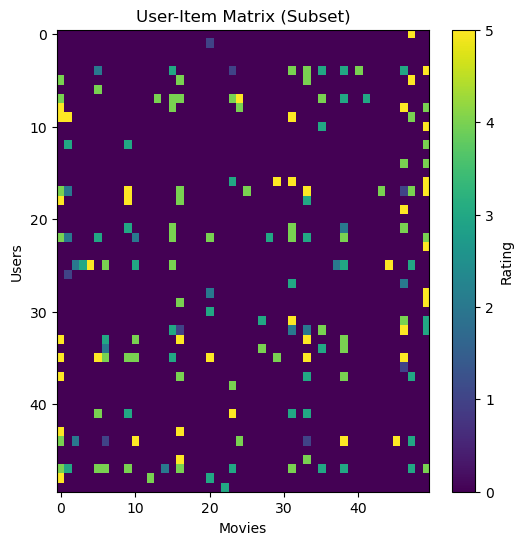

In [65]:
matrix_dense = matrix.toarray()
subset = matrix_dense[:50, :50]
plt.figure(figsize=(6,6))
plt.imshow(subset, aspect='auto')
plt.xlabel("Movies")
plt.ylabel("Users")
plt.title("User-Item Matrix (Subset)")
plt.colorbar(label="Rating")
plt.show()

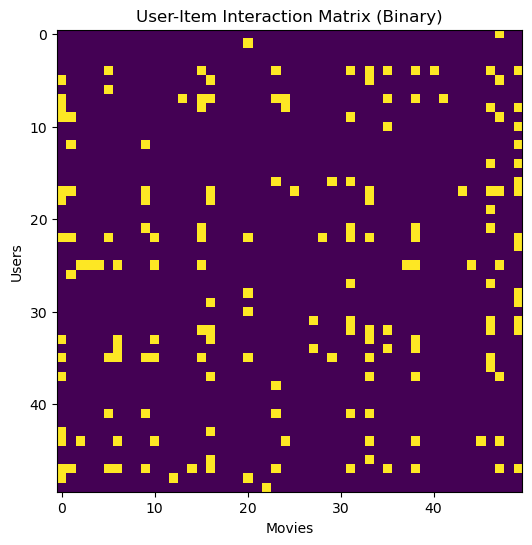

In [67]:
subset_binary = (subset > 0).astype(int)

plt.figure(figsize=(6,6))
plt.imshow(subset_binary, aspect='auto')

plt.xlabel("Movies")
plt.ylabel("Users")
plt.title("User-Item Interaction Matrix (Binary)")

plt.show()

In [69]:
total = matrix.shape[0] * matrix.shape[1]
nonzero = matrix.count_nonzero()

sparsity = 1 - (nonzero / total)

print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9640
